<a href="https://colab.research.google.com/github/taichi0520-hub/my-research-project/blob/main/src/run_Cellpose_SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

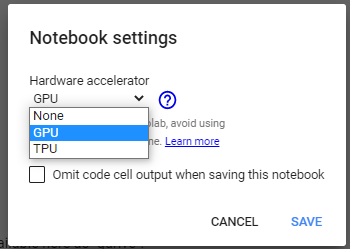

### Google ドライブをマウントする

このセルを実行して、Google ドライブを Colab に接続します：
* URL をクリックします。
* Google アカウントにサインインします。

次のいずれかを行う必要があります：
* 認証コードをコピーして下のボックスに入力する
* 新しい Google Colab では、「許可 (Allow)」をクリックするだけで接続されます。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


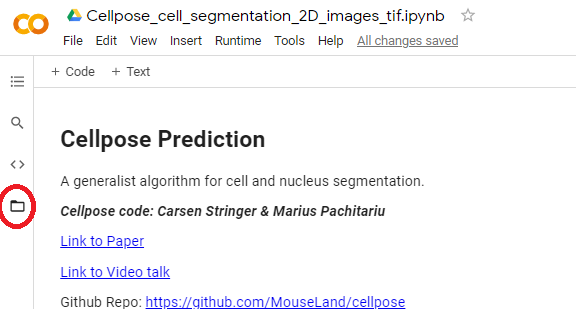

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

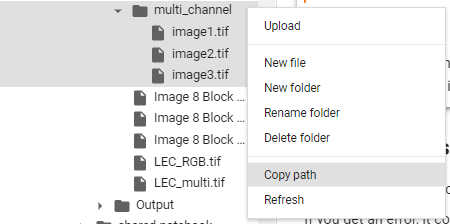

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-k78lg_2t
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-k78lg_2t
  Resolved https://www.github.com/mouseland/cellpose.git to commit a9f8bfcde43033247309e3982747df9fe9f09315
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 80.8 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.1.1-py3-none-any.whl size=213288 sha256=477f5b99c000b140f0e655302bfb8c3e55437106da3dac4afb253868fa92052a
  Stored in directory: /tmp/pip-ephem-wheel-cache-akjlqc8v/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


Check GPU and instantiate model - will download weights.

In [ ]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-04-18 16:32:35,895 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-18 16:32:35,896 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-18 16:32:36,290 [INFO] ** TORCH CUDA version installed and working. **
2026-04-18 16:32:36,292 [INFO] ** TORCH CUDA version installed and working. **
2026-04-18 16:32:36,293 [INFO] >>>> using GPU (CUDA)
2026-04-18 16:32:39,994 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:08<00:00, 145MB/s]


Input directory with your images:

In [ ]:
# Google drive内の画像のパスに変更
dir = "/content/drive/MyDrive/ms1_test"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# その画像の拡張子に変更する（".tif"など）
image_ext = ".jpeg"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
crossjunction_1.jpeg


## Run Cellpose-SAM on one image in folder

変更可能なパラメータは以下のとおりです:

* ***flow_threshold*** は、各マスクのフローの許容される最大誤差です。デフォルトは0.4です。
    * Cellposeが期待するほど多くのマスクを返さない場合は、このしきい値を増やしてください（または0.0にして完全にオフにします）。
    * Cellposeが形のおかしいマスクを多く返しすぎる場合は、このしきい値を減らしてください。

* ***cellprob_threshold*** は、検出されたオブジェクトが細胞である確率を決定します。デフォルトは 0.0 です。
    * Cellposeが期待するほど多くのマスクを返さない場合や、マスクが小さすぎる場合は、このしきい値を減らしてください。
    * Cellposeが特にくすんだ/暗い領域から多くのマスクを返しすぎる場合は、このしきい値を増やしてください。

* ***tile_norm_blocksize***は、画像を正規化するために使用されるブロックのサイズを決定します。デフォルトは 0 で、画像全体がまとめて正規化されることを意味します。画像全体で明るさが非常に不均一な場合は、これを 100〜200 ピクセルに変更することをお勧めします。



In [ ]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1040, 1392, 3). Assuming channel dimension is last with 3 channels


### Channel Selection:

- 以下に表示されるドロップダウンを使用して、セグメンテーションを行う画像のゼロインデックスチャンネルを選択してください。順序は問いません。ドロップダウンを編集した後は、必ずセルを再実行してください。

- ブライトフィールドで撮影された組織画像をお持ちの場合は、チャンネルを調整する必要はありません。

- 複数の染色を含む蛍光画像をお持ちの場合は、細胞質/膜染色を含むチャンネルを1つ、核染色を含むチャンネルを1つ選択し、3番目のチャンネルを「None」に設定してください。複数のチャンネルを選択すると、画像内のすべての構造がセグメンテーションされる可能性があります。もし、3番目の染色（以下に説明）でモデルを再トレーニングした場合は、すべてのチャンネルでセグメンテーションを実行できます。

In [ ]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

2026-04-18 16:35:32,951 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


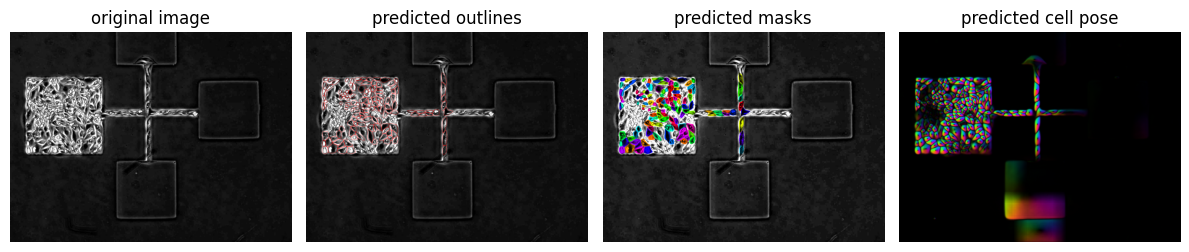

In [ ]:
flow_threshold = 0.4 #各マスクのフローの許容される最大誤差です。デフォルトは0.4です。
cellprob_threshold = 0.0 #検出されたオブジェクトが細胞である確率を決定します。デフォルトは 0.0 です。
tile_norm_blocksize = 0 #画像を正規化するために使用されるブロックのサイズを決定します。デフォルトは 0 です。

# Prepare the 'channels' argument for model.eval
chan_to_segment = None
nuclear_chan = None

# Convert string inputs to int, handle 'None'
if first_channel != 'None':
    chan_to_segment = int(first_channel)
if second_channel != 'None':
    nuclear_chan = int(second_channel)

# Determine the 'channels' argument for Cellpose
cellpose_channels = None # Default to None, Cellpose will try to infer
if chan_to_segment is not None and nuclear_chan is not None:
    cellpose_channels = [chan_to_segment, nuclear_chan]
elif chan_to_segment is not None:
    # If only one channel is specified, assume it's for cytoplasm and no nuclear channel
    cellpose_channels = [chan_to_segment, 0] # 0 indicates no nuclear channel

# Validate channel indices for multi-channel images
if img.ndim == 3:
    num_channels = img.shape[-1]
    if chan_to_segment is not None and chan_to_segment >= num_channels:
        raise IndexError(f"Invalid channel index for segmentation: {chan_to_segment}. Image has only {num_channels} channels.")
    if nuclear_chan is not None and nuclear_chan >= num_channels:
        raise IndexError(f"Invalid channel index for nuclear channel: {nuclear_chan}. Image has only {num_channels} channels.")
elif img.ndim == 2:
    # If image is 2D (grayscale), and a channel is specified, it should be 0.
    # Cellpose can handle 2D images directly, setting channels=[0,0] is common for grayscale.
    if chan_to_segment is not None and chan_to_segment != 0:
        raise ValueError(f"Cannot select channel {chan_to_segment} for a 2D grayscale image. Only channel 0 is implicitly available.")
    if cellpose_channels is None: # If no channels were explicitly set by the dropdowns for a 2D image
        cellpose_channels = [0, 0] # Assume grayscale, use channel 0 for cytoplasm, no nuclear.
    elif chan_to_segment == 0 and nuclear_chan == 0: # If dropdowns explicitly set [0,None] or [0,0]
        cellpose_channels = [0, 0]
    elif chan_to_segment == 0 and nuclear_chan is not None: # User selected a nuclear channel for 2D image
        raise ValueError(f"Cannot select nuclear channel {nuclear_chan} for a 2D grayscale image.")

else:
    raise ValueError(f"Unsupported image dimension: {img.ndim}. Image must be 2D or 3D.")


# Run model evaluation
masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, channels=cellpose_channels)

# Prepare image for plotting
image_to_plot = img
if img.ndim == 3 and chan_to_segment is not None:
    image_to_plot = img[..., chan_to_segment]
elif img.ndim == 3: # if multi-channel but no specific channel selected for plotting, default to first
    image_to_plot = img[..., 0]

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, image_to_plot, masks, flows[0])
plt.tight_layout()
plt.show()

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images

個々の画像サイズが大きい場合、このループで1枚ずつ処理

In [ ]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

100%|██████████| 1/1 [00:13<00:00, 13.57s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

個々の画像サイズが小さいなら、まとめてメモリを読み込み一括処理

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

to save your masks for ImageJ, run the following code:

ImageJで直接開いて、細胞の大きさ、形状、輝度などを簡単に計測・分析できる

In [ ]:
for i in trange(len(files)):
    f = files[i]
    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
    io.save_rois(masks0, f)